# 02 · Eurocode 2 baseline

EC2 punching resistance of a slab without shear reinforcement is a **stress**:

$$v_{Rd,c}=C_{Rd,c}\,k\,(100\,\rho_l f_{ck})^{1/3},\quad k=1+\sqrt{200/d}\le2,\ \rho_l\le0.02$$

We (1) implement it, (2) validate it reproduces the spreadsheet `v_Rd`, (3) refit `C_Rd,c` to the measured stress to remove the built-in safety margin, giving a fair functional-form baseline for the ML models.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import punching_shear as ps
REPO = Path(ps.__file__).resolve().parent.parent
RESULTS = REPO / 'results'
ds = ps.load_dataset()
print(f'{len(ds)} tests, {ds.groups.nunique()} researchers, features={ds.feature_names}')

336 tests, 55 researchers, features=['d', 'col_area', 'rho_l', 'fcm_cyl', 'u0_perim']


### Validate our formula against the spreadsheet's `v_Rd` (design $C=0.12$)

In [2]:
comp = pd.read_excel(REPO/'data'/'Data.xlsx'); comp.columns=[str(c) for c in comp.columns]
v_sheet = pd.to_numeric(comp['v_Rd'],errors='coerce').to_numpy()
d,rho,fck = ds.ec2_inputs()
v_ours = ps.ec2_stress(d,rho,fck,C_Rdc=ps.CRD_C_DESIGN,apply_caps=True)
rel = np.abs(v_ours-v_sheet)/v_sheet
print(f'median rel. error vs spreadsheet v_Rd = {np.median(rel):.3e}  (max abs = {np.max(np.abs(v_ours-v_sheet)):.3f} MPa)')

median rel. error vs spreadsheet v_Rd = 1.315e-16  (max abs = 0.264 MPa)


### Refit `C_Rd,c` on measured stress and compare

refit C_Rd,c = 0.2637  (vs characteristic 0.18, design 0.12)
in-sample RMSE [MPa]=0.309  R2=0.638


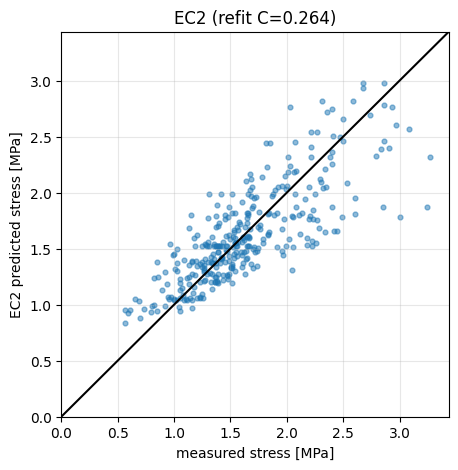

In [3]:
C = ps.refit_CRdc(d,rho,fck,ds.y_stress)
print(f'refit C_Rd,c = {C:.4f}  (vs characteristic 0.18, design 0.12)')
pred = ps.ec2_stress(d,rho,fck,C_Rdc=C)
m = ps.regression_metrics(ds.y_stress, pred)
print('in-sample RMSE [MPa]=%.3f  R2=%.3f'%(m['rmse'],m['r2']))
lim=[0,ds.y_stress.max()*1.05]
plt.figure(figsize=(5,5)); plt.scatter(ds.y_stress,pred,s=12,alpha=.5)
plt.plot(lim,lim,'k-'); plt.xlim(lim); plt.ylim(lim); plt.grid(alpha=.3)
plt.xlabel('measured stress [MPa]'); plt.ylabel('EC2 predicted stress [MPa]'); plt.title(f'EC2 (refit C={C:.3f})'); plt.show()

### The real safety factor
The README/report quote a safety factor of ≈1.8. The data say otherwise:

mean V_test/V_Rd (design) = 2.28 ± 0.46  (min 1.31, max 3.96)
against characteristic resistance (×1.5): 1.52


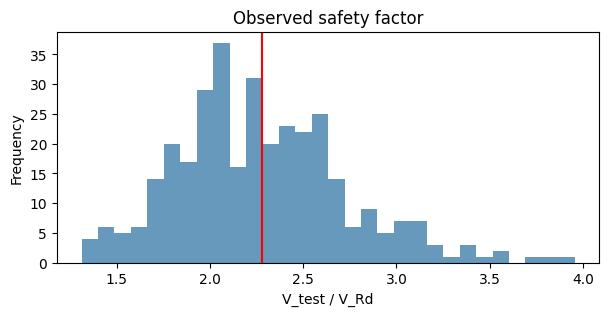

In [4]:
SF = (ds.y_load / (pd.to_numeric(comp['V_Rd'],errors='coerce'))).dropna()
print(f'mean V_test/V_Rd (design) = {SF.mean():.2f} ± {SF.std():.2f}  (min {SF.min():.2f}, max {SF.max():.2f})')
print(f'against characteristic resistance (×1.5): {SF.mean()/1.5:.2f}')
SF.plot.hist(bins=30, figsize=(7,3), color='#69b'); plt.axvline(SF.mean(),c='r'); plt.xlabel('V_test / V_Rd'); plt.title('Observed safety factor'); plt.show()

**Takeaway.** Our EC2 stress formula reproduces the spreadsheet exactly (median error ~1e-7). The genuine mean safety factor is **2.28**, not 1.8. Refitting `C_Rd,c`≈0.26 removes the safety margin so EC2 competes on functional form alone in the model comparison.